In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

Refaire la même chose avec un réseau de neurones à 2 couches cachées.

In [2]:
class MLP(nn.Module):
    def __init__(self, dims):
        super(MLP, self).__init__()
        self.fcs = nn.ModuleList(
            [nn.Linear(dims[i], dims[i+1]) for i in range(len(dims)-1)]
        )
        self.act = nn.Tanh()

    def forward(self, x):
        for fc in self.fcs:
            x = self.act(fc(x))
        return x

Refaire à la main le forward pass

In [3]:
model = MLP([3, 4, 4, 1])
x = torch.Tensor([2.0, 3.0, -1.0])
model(x)

tensor([0.0045], grad_fn=<TanhBackward0>)

In [4]:
model.state_dict()

OrderedDict([('fcs.0.weight',
              tensor([[ 0.4973,  0.2807, -0.4678],
                      [-0.4098, -0.2906, -0.0097],
                      [ 0.3246, -0.0062, -0.0028],
                      [-0.1532, -0.1133,  0.1608]])),
             ('fcs.0.bias', tensor([ 0.4205,  0.4034, -0.3944,  0.4017])),
             ('fcs.1.weight',
              tensor([[ 0.0313,  0.1921,  0.0578,  0.1565],
                      [ 0.4764,  0.3551, -0.4426, -0.3596],
                      [ 0.3330, -0.0040, -0.1484,  0.2661],
                      [ 0.4818, -0.3760, -0.1746, -0.1825]])),
             ('fcs.1.bias', tensor([-0.4539,  0.0680, -0.3587, -0.3711])),
             ('fcs.2.weight', tensor([[ 0.4681, -0.2242,  0.4615,  0.3940]])),
             ('fcs.2.bias', tensor([0.2319]))])

In [5]:
xs = torch.Tensor([
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
])
ys = torch.Tensor([1.0, -1.0, -1.0, 1.0]).view(-1, 1)

In [6]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

for k in range(20):
  
  # forward pass
  ypred = model(xs)
  loss = F.mse_loss(ypred, ys)
  
  # backward pass
  loss.backward()
  
  # update
  optimizer.step()
  optimizer.zero_grad()
  
  print(k, loss.data.item())

0 0.9722117781639099
1 0.9120057821273804
2 0.8612470626831055
3 0.8105483055114746
4 0.7537482976913452
5 0.686194658279419
6 0.6053858995437622
7 0.5132499933242798
8 0.41761815547943115
9 0.3293117880821228
10 0.2562031149864197
11 0.20020094513893127
12 0.15893206000328064
13 0.12875229120254517
14 0.10645487904548645
15 0.0896817073225975
16 0.07680679857730865
17 0.06672661751508713
18 0.05868827551603317
19 0.052170734852552414


Maintenant on arrête de jouer avec notre caca

In [7]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
import torchvision.transforms as T
import matplotlib.pyplot as plt
from torch.utils.data import ConcatDataset

In [8]:
# Download training data from open datasets.
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=T.Compose([T.ToTensor()]),
)

# Download test data from open datasets.
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=T.Compose([T.ToTensor()]),
)

In [9]:
# Quelque manipulation sur le set de données
print(training_data)
print(training_data.data.shape)
print(training_data.targets.shape)
print(training_data.targets.unique())
print(training_data.targets.bincount())

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
           )
torch.Size([60000, 28, 28])
torch.Size([60000])
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
tensor([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949])


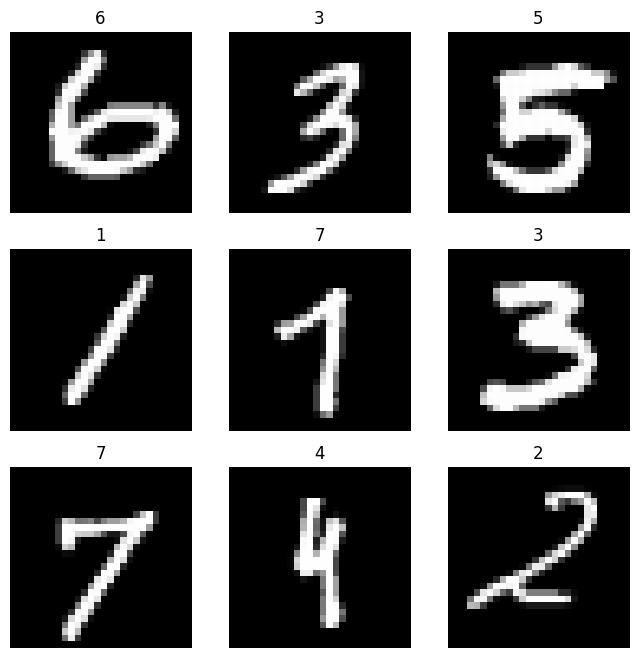

In [10]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

We pass the Dataset as an argument to DataLoader. This wraps an iterable over our dataset, and supports automatic batching, sampling, shuffling and multiprocess data loading. Here we define a batch size of 64, i.e. each element in the dataloader iterable will return a batch of 64 features and labels.

In [11]:
batch_size = 64

# Create data loaders.
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break

Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64


In [12]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

Feature batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


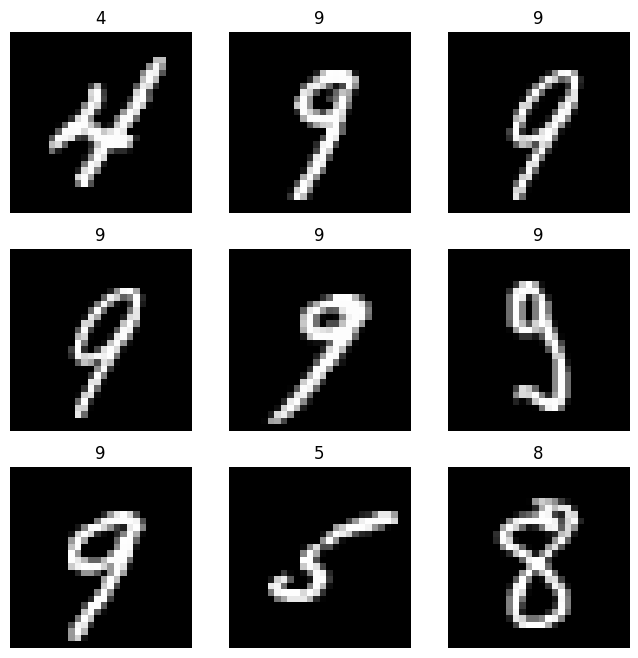

In [13]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(train_features.size()[0], size=(1,)).item()
    img, label = train_features[sample_idx], train_labels[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label.item())
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [14]:
class MLP(nn.Module):
    def __init__(self, dims):
        super(MLP, self).__init__()
        self.fcs = nn.ModuleList(
            [nn.Linear(dims[i], dims[i+1]) for i in range(len(dims)-1)]
        )
        self.act = nn.ReLU()
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.flatten(x)
        for fc in self.fcs:
            x = self.act(fc(x))
        return x

In [15]:
input_dim = 28 * 28
output_dim = 10

In [16]:
model = MLP([input_dim, 128, 128, output_dim])

Initilisation Criteriem + optimizer

In [17]:
loss_fn = nn.CrossEntropyLoss() # CrossEntropyLoss expects raw logits
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

In [18]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [19]:
epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1
-------------------------------
loss: 2.306644  [   64/60000]
loss: 1.031773  [ 6464/60000]
loss: 0.873828  [12864/60000]
loss: 1.044614  [19264/60000]
loss: 1.036964  [25664/60000]
loss: 0.921035  [32064/60000]
loss: 0.746268  [38464/60000]
loss: 0.785904  [44864/60000]
loss: 1.025393  [51264/60000]
loss: 0.760301  [57664/60000]
Test Error: 
 Accuracy: 67.4%, Avg loss: 0.839145 

Epoch 2
-------------------------------
loss: 0.929804  [   64/60000]
loss: 0.818706  [ 6464/60000]
loss: 0.699491  [12864/60000]
loss: 0.910780  [19264/60000]
loss: 0.940506  [25664/60000]
loss: 0.866996  [32064/60000]
loss: 0.694547  [38464/60000]
loss: 0.696229  [44864/60000]
loss: 0.942786  [51264/60000]
loss: 0.708508  [57664/60000]
Test Error: 
 Accuracy: 68.2%, Avg loss: 0.804200 

Epoch 3
-------------------------------
loss: 0.878853  [   64/60000]
loss: 0.810735  [ 6464/60000]
loss: 0.707867  [12864/60000]
loss: 0.911877  [19264/60000]
loss: 0.894014  [25664/60000]
loss: 0.807165  [32064/600

PEUT BIEN MIEUX FAIRE
AMELIORONS TOUT

In [21]:
# Download training data from open datasets.
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=T.Compose([T.ToTensor()]),
)

# Download test data from open datasets.
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=T.Compose([T.ToTensor()]),
)

In [22]:
# Initialize variables to calculate mean and std
mean = 0.0
std = 0.0

combined_data = ConcatDataset([training_data, test_data])

# Iterate over the training set
for image, label in combined_data:
    # Calculate the mean and std for each channel (MNIST has a single channel)
    image = image.view(28 * 28)  # Flatten the image
    mean += image.mean().sum()
    std += image.std().sum()

# Compute final mean and std
mean /= combined_data.__len__()
std /= combined_data.__len__()

print(f"Mean: {mean}")
print(f"Std: {std}")

Mean: 0.13092496991157532
Std: 0.30183959007263184


In [23]:
# Download training data from open datasets.
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=T.Compose([T.ToTensor(), T.Normalize((mean), (std))]),
)

# Download test data from open datasets.
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=T.Compose([T.ToTensor(), T.Normalize((mean), (std))]),
)

In [24]:
# Initialize variables to calculate mean and std
mean = 0.0
std = 0.0

combined_data = ConcatDataset([training_data, test_data])

# Iterate over the training set
for image, label in combined_data:
    # Calculate the mean and std for each channel (MNIST has a single channel)
    image = image.view(28 * 28)  # Flatten the image
    mean += image.mean().sum()
    std += image.std().sum()

# Compute final mean and std
mean /= combined_data.__len__()
std /= combined_data.__len__()

print(f"Mean: {mean}")
print(f"Std: {std}")

Mean: 1.2540766647362034e-06
Std: 0.9999989867210388


In [25]:
train_dataloader = DataLoader(training_data, batch_size=batch_size, num_workers=4, pin_memory=True, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size, num_workers=4, pin_memory=True)

In [26]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

In [27]:
model = NeuralNetwork()
loss_fn = nn.CrossEntropyLoss() # CrossEntropyLoss expects raw logits
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

Epoch 1/10


loss: 2.296777  [   64/60000]
loss: 0.149134  [ 6464/60000]
loss: 0.353688  [12864/60000]
loss: 0.458455  [19264/60000]
loss: 0.060213  [25664/60000]
loss: 0.038136  [32064/60000]
loss: 0.166809  [38464/60000]
loss: 0.206315  [44864/60000]
loss: 0.080413  [51264/60000]
loss: 0.183556  [57664/60000]
Test Error: 
 Accuracy: 96.3%, Avg loss: 0.125450 

Epoch 1/10 complete

Epoch 2/10
loss: 0.110468  [   64/60000]
loss: 0.150478  [ 6464/60000]
loss: 0.182819  [12864/60000]
loss: 0.129033  [19264/60000]
loss: 0.112539  [25664/60000]
loss: 0.116529  [32064/60000]
loss: 0.040990  [38464/60000]
loss: 0.106657  [44864/60000]
loss: 0.122897  [51264/60000]
loss: 0.075231  [57664/60000]
Test Error: 
 Accuracy: 97.4%, Avg loss: 0.084067 

Epoch 2/10 complete

Epoch 3/10
loss: 0.023117  [   64/60000]
loss: 0.217001  [ 6464/60000]
loss: 0.151706  [12864/60000]
loss: 0.021372  [19264/60000]
loss: 0.004350  [25664/60000]
loss: 0.074261  [32064/60000]
loss: 0.000858  [38464/60000]
loss: 0.017591  [44864

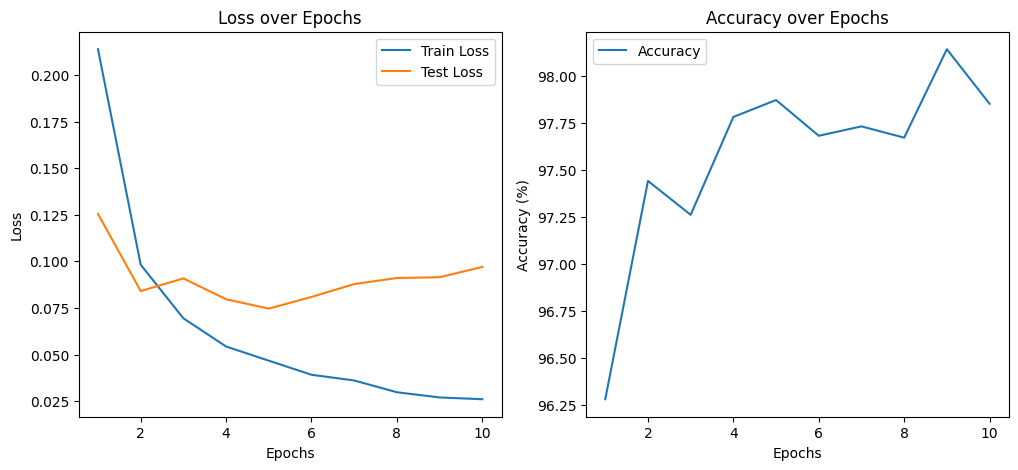

In [28]:
# Lists to store metrics
train_losses = []
test_losses = []
accuracies = []

def train_loop(dataloader, model, loss_fn, optimizer, batch_size):
    size = len(dataloader.dataset)
    model.train()
    epoch_loss = 0
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")

    return epoch_loss / len(dataloader)

def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    accuracy = 100 * correct
    print(f"Test Error: \n Accuracy: {accuracy:>0.1f}%, Avg loss: {test_loss:>8f} \n")

    return test_loss, accuracy


# Function to plot the metrics
def plot_metrics(train_losses, test_losses, accuracies):
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(12, 5))

    # Plot training and test loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss')
    plt.plot(epochs, test_losses, label='Test Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Loss over Epochs')

    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, accuracies, label='Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.title('Accuracy over Epochs')

    plt.show()


# Training loop with added graphing
def train_and_test(dataloader_train, dataloader_test, model, loss_fn, optimizer, epochs, batch_size):
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")

        # Train the model
        train_loss = train_loop(dataloader_train, model, loss_fn, optimizer, batch_size)
        train_losses.append(train_loss)

        # Test the model
        test_loss, accuracy = test_loop(dataloader_test, model, loss_fn)
        test_losses.append(test_loss)
        accuracies.append(accuracy)

        print(f"Epoch {epoch+1}/{epochs} complete\n")

    # After all epochs are done, plot the metrics
    plot_metrics(train_losses, test_losses, accuracies)

train_and_test(train_dataloader, test_dataloader, model, loss_fn, optimizer, epochs, batch_size)

In [29]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv_stack = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), # 1, 28, 28 -> 32, 28, 28
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 1, 28, 28 -> 32, 28, 28
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2), # 32, 28, 28 -> 32, 14, 14
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 32, 14, 14 -> 64, 14, 14
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Conv2d(128, 128, kernel_size=3, padding=1), # 64, 14, 14 -> 128, 14, 14
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Dropout(0.2),
            nn.MaxPool2d(kernel_size=2, stride=2)) # 128, 14, 14 -> 128, 7, 7

        self.FC_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*7*7, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.FC_stack(self.conv_stack(x))

In [30]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using {} device".format(device))

Using cuda device


In [31]:
model = CNN().to(device)
loss_fn = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

In [32]:
from torch.utils.tensorboard import SummaryWriter

In [33]:
writer = SummaryWriter('runs/mnist_experiment_1')

In [45]:
def train_loop(dataloader, model, loss_fn, optimizer, batch_size):
    model.train()
    epoch_loss = 0
    correct = 0
    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    return epoch_loss / len(dataloader), correct / len(dataloader.dataset) * 100

def test_loop(dataloader, model, loss_fn):
    model.eval()
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    return test_loss / len(dataloader), correct / len(dataloader.dataset) * 100

# Training loop with added graphing
def train_and_test(dataloader_train, dataloader_test, model, loss_fn, optimizer, epochs, batch_size):
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")

        # Train the model
        train_loss, accuracy = train_loop(dataloader_train, model, loss_fn, optimizer, batch_size)
        writer.add_scalars('Loss', {'train': train_loss}, epoch)
        writer.add_scalars('Accuracy', {'train': accuracy}, epoch)

        # Test the model
        test_loss, accuracy = test_loop(dataloader_test, model, loss_fn)
        writer.add_scalars('Loss', {'test': test_loss}, epoch)
        writer.add_scalars('Accuracy', {'test': accuracy}, epoch)

        print(f"Epoch {epoch+1}/{epochs} complete\n")

train_and_test(train_dataloader, test_dataloader, model, loss_fn, optimizer, epochs, batch_size)

Epoch 1/10
Epoch 1/10 complete

Epoch 2/10
Epoch 2/10 complete

Epoch 3/10
Epoch 3/10 complete

Epoch 4/10
Epoch 4/10 complete

Epoch 5/10
Epoch 5/10 complete

Epoch 6/10
Epoch 6/10 complete

Epoch 7/10
Epoch 7/10 complete

Epoch 8/10
Epoch 8/10 complete

Epoch 9/10
Epoch 9/10 complete

Epoch 10/10
Epoch 10/10 complete



In [52]:
model.to("cpu")
torch_input = torch.randn(1, 1, 28, 28)
onnx_program = torch.onnx.export(
    model, 
    torch_input, 
    "model.onnx", 
    verbose=True,
    input_names=["input"], 
    output_names=["output"],
    opset_version=11,
    export_params=True,
    do_constant_folding=True,
    dynamic_axes={
        'input' : {0 : 'batch_size'},    # variable length axes
        'output' : {0 : 'batch_size'}
        }
)

Exported graph: graph(%input : Float(*, 1, 28, 28, strides=[784, 784, 28, 1], requires_grad=0, device=cpu),
      %conv_stack.0.weight : Float(32, 1, 3, 3, strides=[9, 9, 3, 1], requires_grad=1, device=cpu),
      %conv_stack.0.bias : Float(32, strides=[1], requires_grad=1, device=cpu),
      %conv_stack.3.weight : Float(64, 32, 3, 3, strides=[288, 9, 3, 1], requires_grad=1, device=cpu),
      %conv_stack.3.bias : Float(64, strides=[1], requires_grad=1, device=cpu),
      %conv_stack.6.weight : Float(64, strides=[1], requires_grad=1, device=cpu),
      %conv_stack.6.bias : Float(64, strides=[1], requires_grad=1, device=cpu),
      %conv_stack.6.running_mean : Float(64, strides=[1], requires_grad=0, device=cpu),
      %conv_stack.6.running_var : Float(64, strides=[1], requires_grad=0, device=cpu),
      %conv_stack.8.weight : Float(128, 64, 3, 3, strides=[576, 9, 3, 1], requires_grad=1, device=cpu),
      %conv_stack.8.bias : Float(128, strides=[1], requires_grad=1, device=cpu),
      %

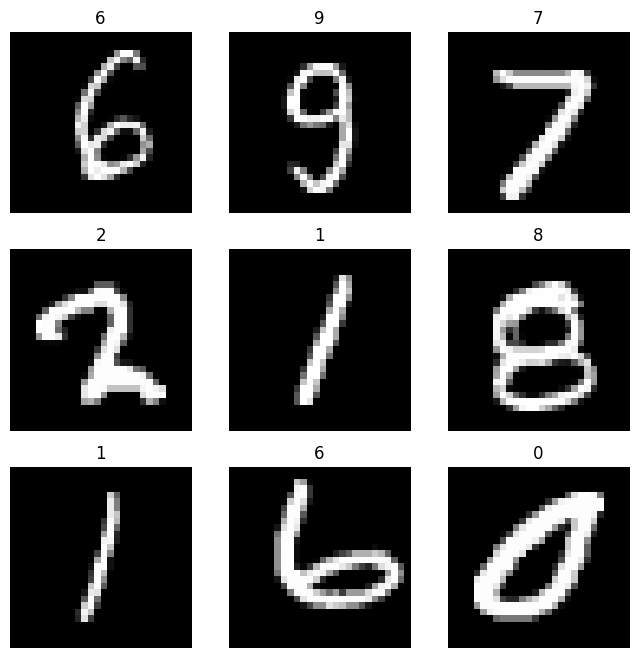

In [53]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [58]:
training_data[sample_idx][0]

tensor([[[-0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338,
          -0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338,
          -0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338,
          -0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338],
         [-0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338,
          -0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338,
          -0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338,
          -0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338],
         [-0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338,
          -0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338,
          -0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338,
          -0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338],
         [-0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338, -0.4338,
          -0.4338, -0.4338, -0.4338, -0.4338, -0

In [59]:
# Download training data from open datasets.
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=T.Compose([T.ToTensor()]),
)
training_data[sample_idx][0]

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,